# Trying to explain ML models using local explainers: SHAP and LIME

In this post I want to explain how SHAP and LIME techniques works using [Mobile Price Classification dataset](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification), creating a model to classify phone's price range and try to find an explanation about how models makes its predictions.

## SHAP
SHAP is a technique for explaining ML models using local instances, is based on game's theory of shapley's values. This technique is model agnostic, so it doesn't care what model are you traying to explain, it can calculate an approximate value of the feature's SHAP value.  
This method is based on the cooperative game's theory where the question was "how can I measure the contribution of each player to the final result of a match?", the same approach can be extrapolated to ML models, instead of players, we got data features.

### SHAP values
SHAP values are like the measure of contribution of some feature to a model prediction. SHAP values capture the marginal contribution of each feature to the final prediction. In other words, is the impact of having a certain for a value given feature in comparison to the prediction we'd make if that feature took some baseline value.

### How does it works?
Technique works creating an approximation of SHAP values based on some data, it takes actual model output and a baseline output following this equallity:

<center>
    $\sum_{shap_value \in SHAP_values} = model output - pred for baseline values$
</center>

to calculate baseline values it requires data instances, and the perfoms a calculation of a calculates a weighted mean average payoff gain that a single feature provides when included in all cases where is excluded, this is like asking "how many goals on average the team lose or win if a 'remove' Ronaldo or Messi in some soccer matches?".

### Procedure
1. Train ML model
2. Create a SHAP explainer instance for the model.
3. Calculate values SHAP values using **testing** or **validation datasets**.
4. Create some plots to from SHAP values.

In [25]:
from pandas import read_csv
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

data = read_csv("/kaggle/input/datasets/iabhishekofficial/mobile-price-classification/train.csv")
COL_MAPPER = {"fc": "front_camera_pixels", "four_g": "has_4g", "int_memory": "storage_size", 
              "mobile_wt": "weight", "m_dep": "depth_cm", "n_cores": "cpu_cores", "pc": "rear_camera_pixels",
              "px_width": "screen_width_pixels", "px_height": "screen_height_pixels", "sc_w": "screen_width_cm",
              "sc_h": "screen_height_cm", "three_g": "has_3g", "touch_screen": "has_touch_screen", "wifi": "has_wifi",
              "blue": "has_bluetooth", "clock_speed": "cpu_clock_speed"}

renamed_data = data.rename(columns=COL_MAPPER)

NUMS = ["battery_power","cpu_clock_speed", "depth_cm", "front_camera_pixels", "storage_size", "weight", "cpu_cores",
       "rear_camera_pixels", "screen_height_pixels","screen_width_pixels","ram","screen_height_cm","screen_width_cm","talk_time"]
BINS = ["has_4g", "has_3g", "has_bluetooth", "dual_sim", "has_wifi", "has_touch_screen"]
FEATURES = NUMS + BINS
TAG = "price_range"

x_train, x_test, y_train, y_test = train_test_split(renamed_data[FEATURES], renamed_data[TAG], train_size=0.8, random_state=123)

TRANSFORMER = ColumnTransformer([("normalized", StandardScaler(), NUMS)],
                                remainder="passthrough", # Unstransformed data is still into the dataframe
                                verbose_feature_names_out=False # Feature names are not changed after transforming
                               )

# Setting output as pandas dataframe
TRANSFORMER.set_output(transform="pandas")

X_train = TRANSFORMER.fit_transform(x_train)
X_test = TRANSFORMER.transform(x_test)

# Model definition
MODEL = RandomForestClassifier(random_state=123, n_estimators=3, max_depth=8, criterion="gini")
MODEL.fit(X_train, y_train)
y_pred = MODEL.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1Score = f1_score(y_test, y_pred, average="weighted")
print(f"Accuracy: {(accuracy*100):2f} %")
print(f"Weighted F1-Score: {(f1Score*100):2f} %")

Accuracy: 69.250000 %
Weighted F1-Score: 68.524685 %


So, the classifier is trained and ready to be used on `shap` library, so this is a multiclass problem, then SHAP values area going to be calculated for every class.  
We are using a random forest classifier, so we must use `TreeExplainer` from `shap` library, we must pass the model and test dataset.

In [3]:
from shap import TreeExplainer, initjs, summary_plot, Explainer, datasets
from shap.plots import violin, waterfall, force, bar, scatter

initjs()
shap_explainer = TreeExplainer(MODEL)
shap_values = shap_explainer.shap_values(X_test, y_test)
explanation = shap_explainer(X_test, y_test)

Explainer model will have an expected/baseline value for each class

In [23]:
# First dimension is the row instance
# Second are the features
# Third are the classes
shap_values.shape

(400, 20, 4)

### Plots
#### Violin plot (previously summary plot)
Shows the significance of feature values due to models classification for each instances. Each dot is a row instance, color represents the feature value, y-axis is the regarding feature and x-axis is the respective SHAP value. **This plot is designed to be used on dataset, not just in a single instance**.

In this case, positive SHAP values tell us how  much each feature contributes to classify an instance in this class. For example, in the following chart, "ram" feature has been taken as the most important feature. Watching its values, we can detail that mobile phones with too small ram sizes are classified into the cheapest price category ('Category 0')and higher values are predicted in more expensive classes.

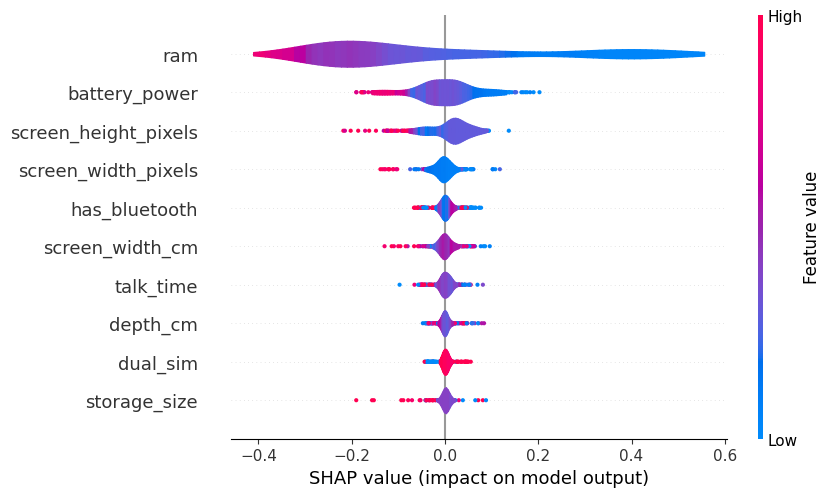

In [35]:
violin(shap_values[:, :, 0], X_test, max_display=10)

This is a summary plot using a bars instead of a violin plot, in the chart we can see how much a feature contributes to a model classification to each class. Keepp in mind that the chart is telling us which are the most important, not how does each feature impacts for a single class (negative or possitive).

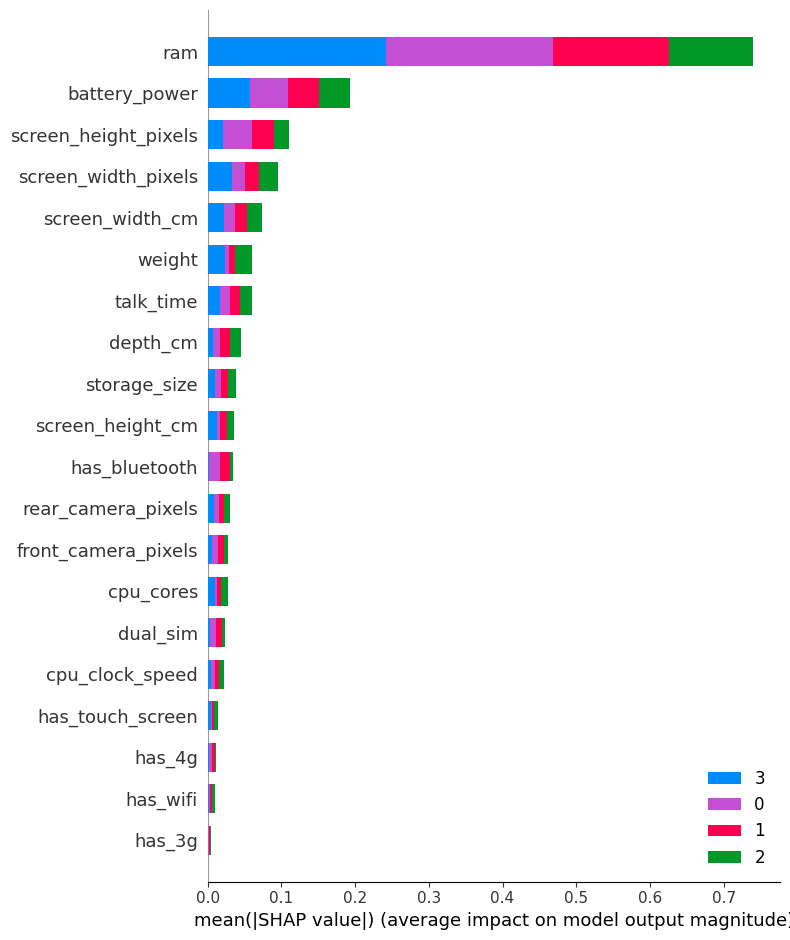

In [16]:
summary_plot(shap_values, X_test, plot_type="bar", class_names=MODEL.classes_, feature_names=X_test.columns)

#### Force plot
This plot is a summary of the previous, allow us to see how each attribute contibutes to a specific model predticion, for instance, in this case the expected value was 0.20 and instance belongs to class `1`, we see that `ram` attribute has the highest positive influence, so, we could say that is a deterministic attribute to classify the instance at class 1. Also `cpu_scores` field is a strong attribute, so we can state that hardware characteristics are the main features that the model bases its prediction.  
Negative SHAP values show that minor features like having bluetooth, creen resolution or camera have the strongest effect on telling the model "hey, this record doesn't belongs to price range '1'", however, ram effect is higher than 3 highest negative SHAP values.

In [38]:
force(shap_explainer.expected_value[1], shap_values[0, :, 1], X_train.columns)

Also we can check the behavior of more than 1 instance in a single chart to see trends or patterns abour how the model classifies instances. At x-axis shows instance ID, Y-axis are the SHAP values and line in the are charts denotes attributes, try to pass the mouse over chart on some different areas a you will check that legend changes when you move from an instance to another. You can select a single attribute to be analyzed too.

In [7]:
force(shap_explainer.expected_value[1], shap_values[0:3, :, 1], X_train.columns)

#### Waterfall plot
Designed to explain single instance, it shows the expected value (X-axis) compared with the real value (Y-axis), each row is a feature contribution to the final prediction, beign positive contributions red and negatives blue. Wigth this chart you can see how baseline value moves to achieve target $Y$ value.

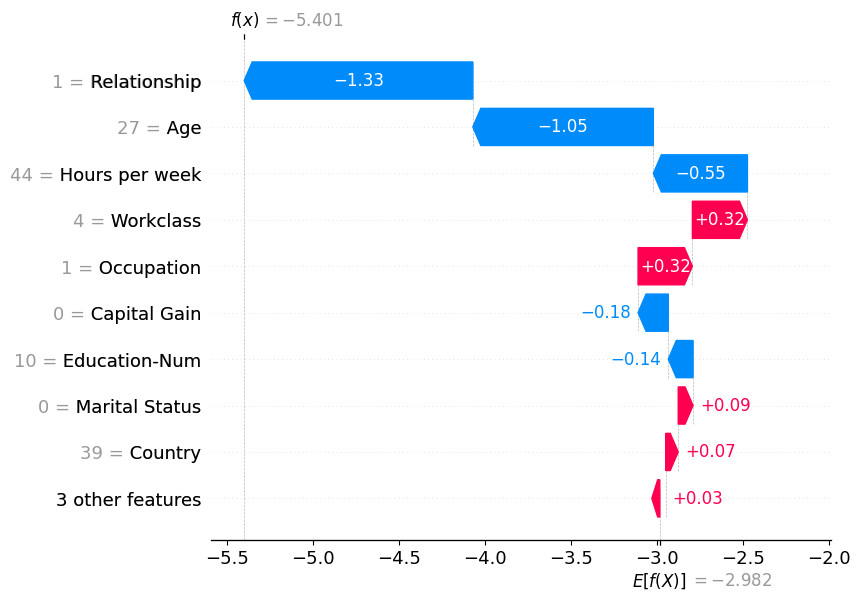

In [23]:
from xgboost import XGBClassifier

X, y = datasets.adult(n_points=2000)
OTHER_MODEL = XGBClassifier().fit(X, y)

# compute SHAP values
explainer = Explainer(model, X)
SHAP_VALUES = explainer(X)

waterfall(SHAP_VALUES[0])

#### Bar plot
Shows the importance of each feature from calculating the absolute mean of SHAP values.

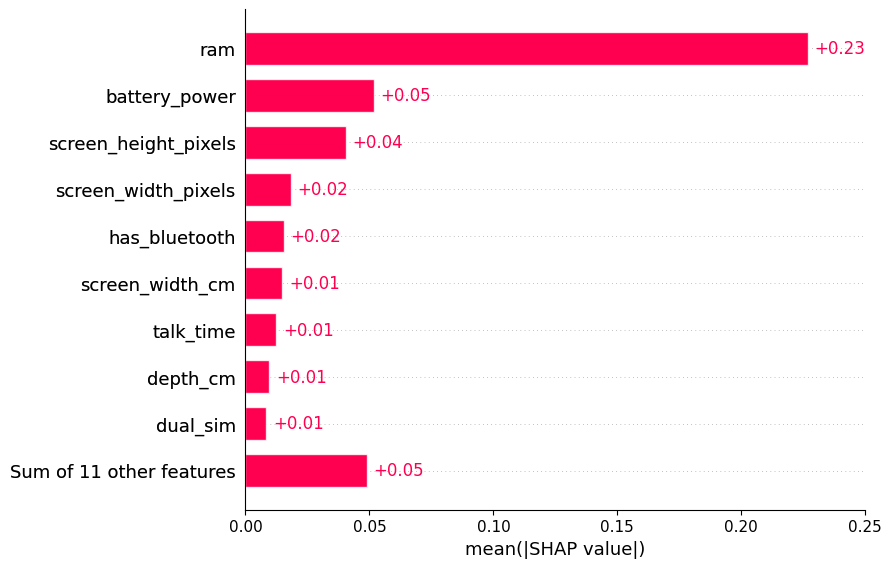

In [13]:
bar(explanation[:,:,0])

When a single instance is passed, a local explanation transforms plot shape like a waterfall plot, but X-axis show SHAP values instead of expected values. As force and violin plot, just explains one class at once.

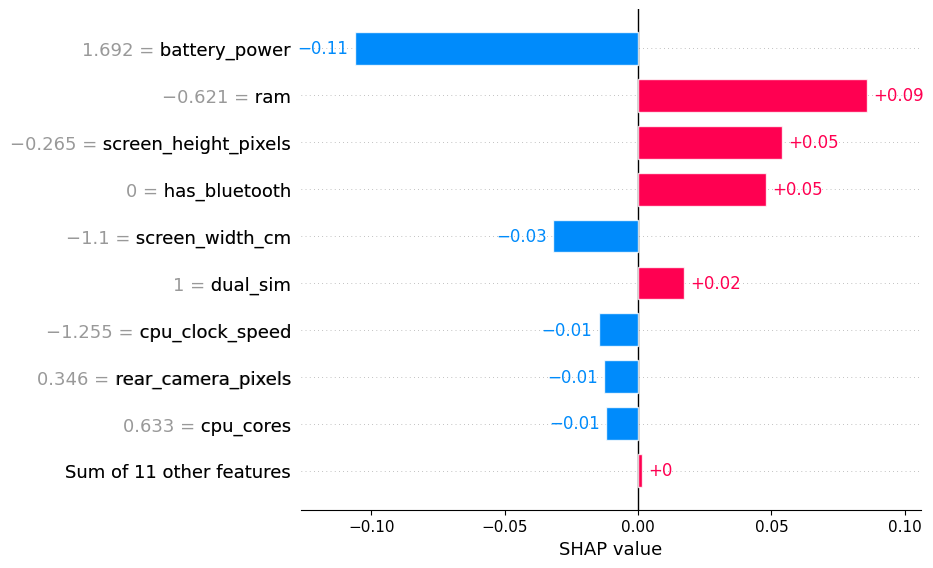

In [19]:
bar(explanation[0,:,0])

#### Dependence contribution/scatter plot
Works like a simple scatter plot linking a feature with its SHAP value for each data instance.
- X-axis is the value of the feature
- Y-axis is the SHAP value for the feature
- The plot shows a small histogram at the bottom representing the values distribution.

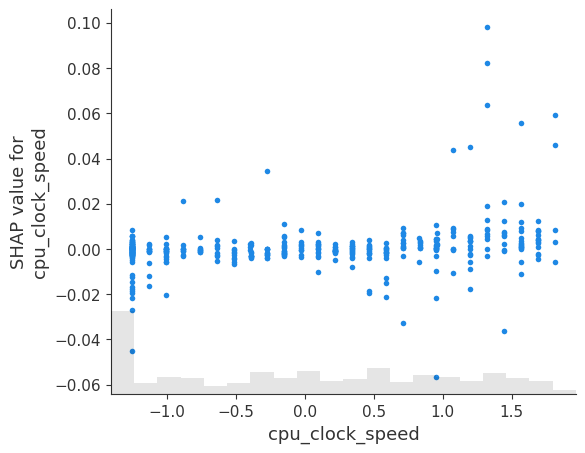

In [12]:
# Looking for patterns in class "0" on "cpu_clock_speed" attribute
scatter(explanation[:, "cpu_clock_speed", 0])

Also we can add a feature to assess interactions with another feature adding a second feature like a heatmap. `shap` selects tries to select the field that could have and effect on the studying variables, but we can use our own field.

**Selecting the related attribute automatically:**

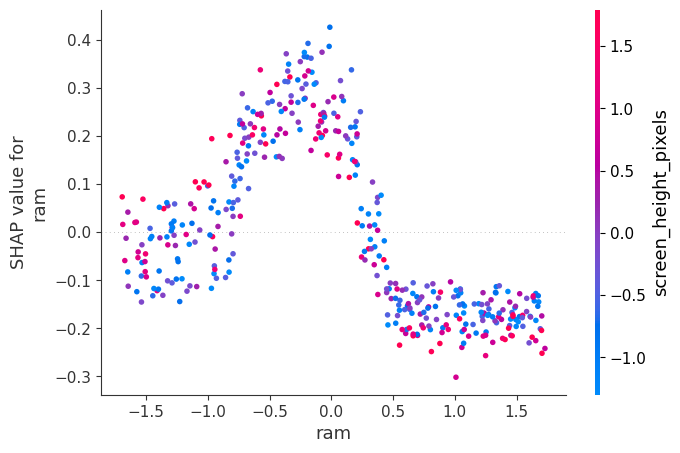

In [19]:
# Looking for patterns in "ram" attribute and an undefined linked field
scatter(explanation[:, "ram", 1], explanation[:, :, 1], hist=False)

**Manual selection of the attribute:**

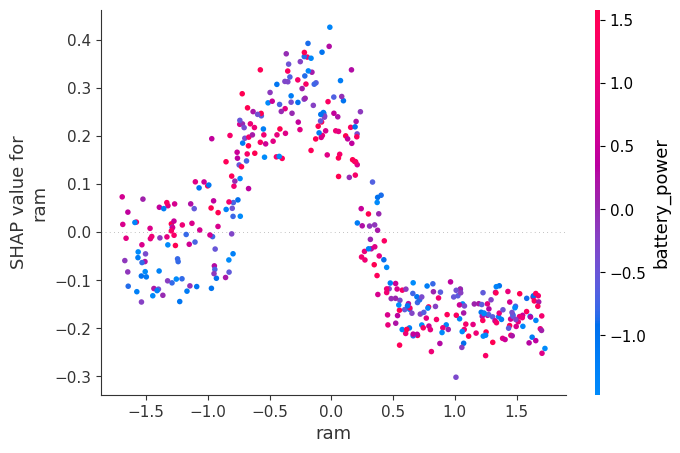

In [18]:
scatter(explanation[:, "ram", 1], explanation[:, "battery_power", 1], hist=False)